In [11]:
import pandas as pd

df = pd.read_csv("../data/raw/dataset.csv")

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/dataset.csv")

Section 1: Basic Info

In [15]:
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nFirst 5 Rows")
display(df.head())

Dataset Shape
(7043, 21)

Columns
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Data Types
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn           

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Missing Values

In [16]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [17]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


Variable Distribution

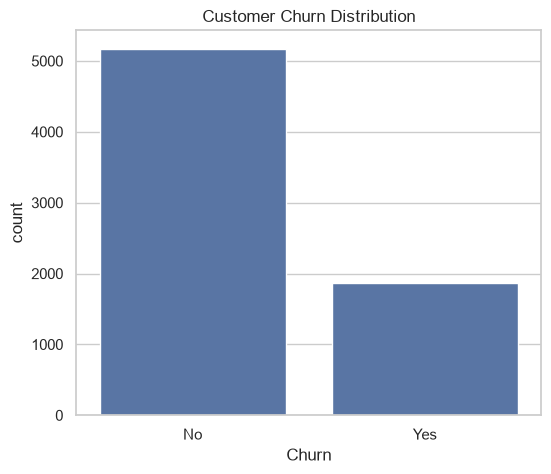

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [18]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.show()

print(df["Churn"].value_counts())

print(df["Churn"].value_counts(normalize=True)*100)

Numerical Features

In [19]:
numerical = df.select_dtypes(include=np.number).columns

print(numerical)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')


In [20]:
df[numerical].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


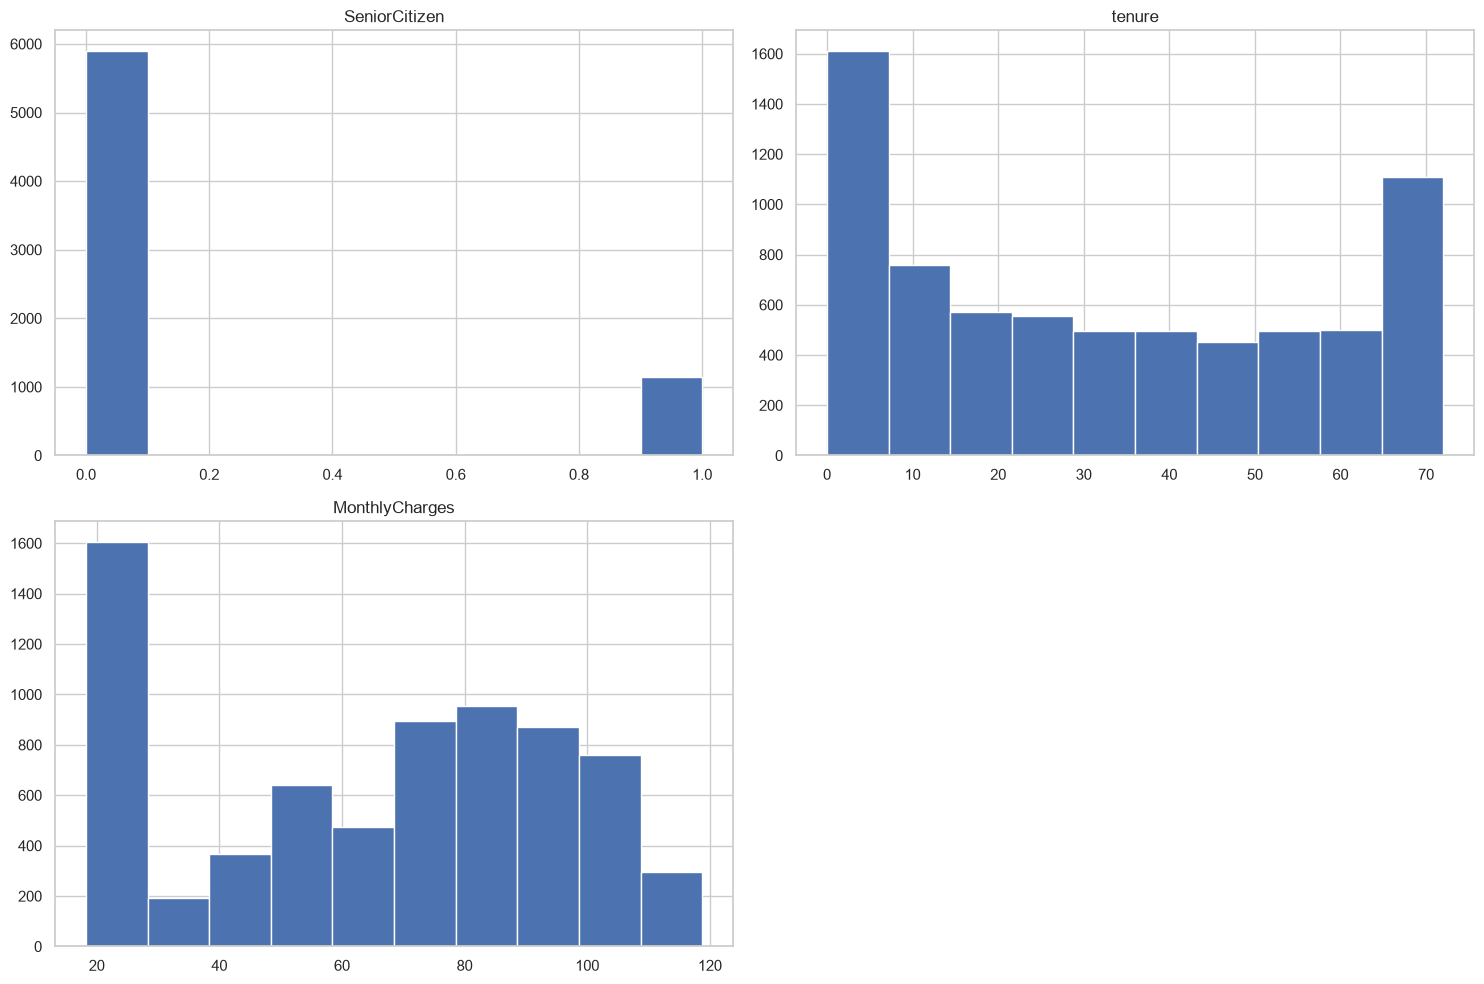

In [21]:
df[numerical].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

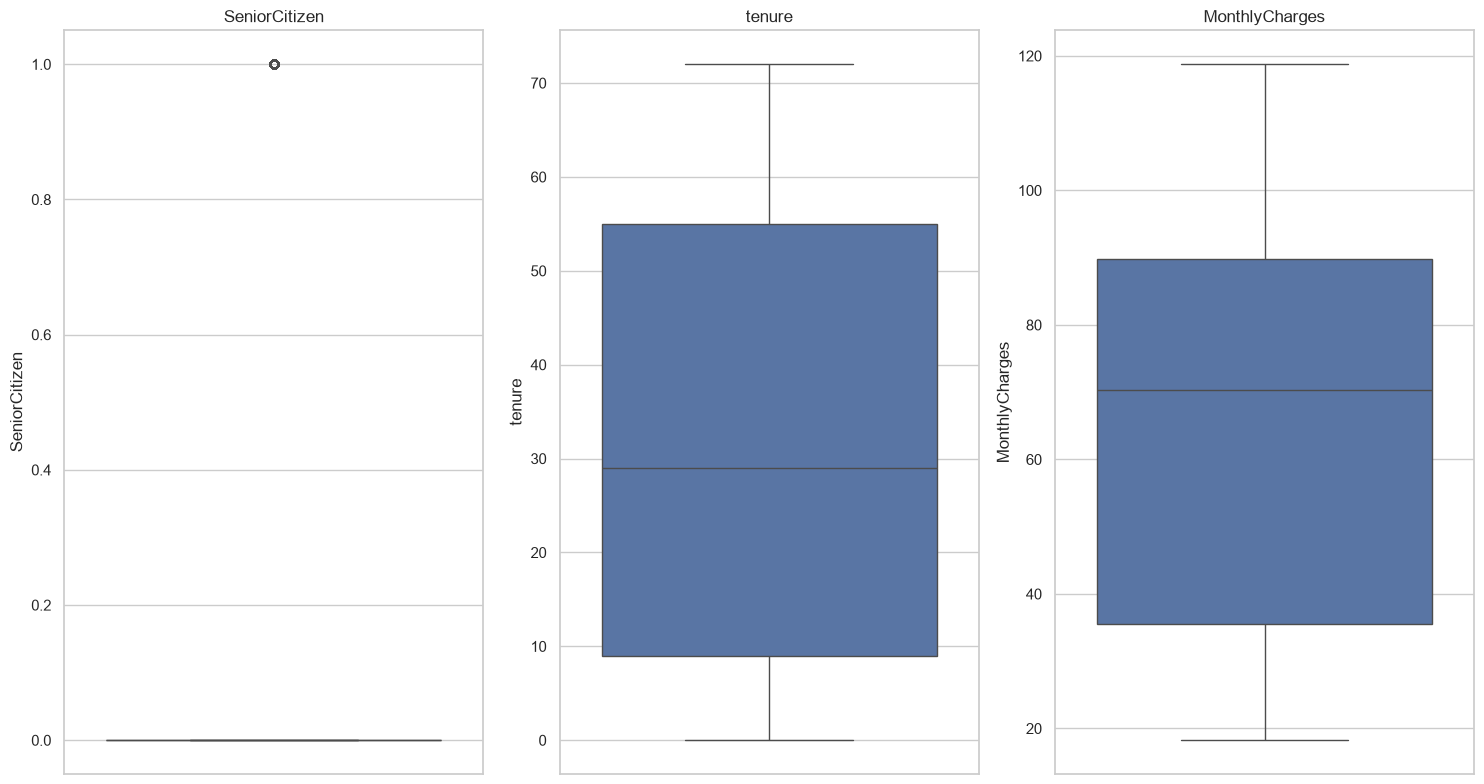

In [22]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical):
    plt.subplot((len(numerical)+2)//3, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Customers paying more every month appear more likely to leave, possibly because they are more price-sensitive or perceive insufficient value.

New customers are at the highest risk of churn.

In [23]:
categorical = df.select_dtypes(include="object").columns

print(categorical)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')


C:\Users\sansi\AppData\Local\Temp\ipykernel_31724\2614588957.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include="object").columns


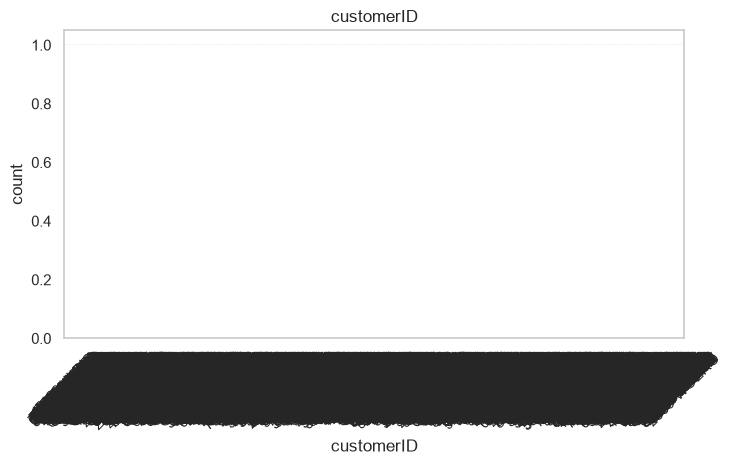

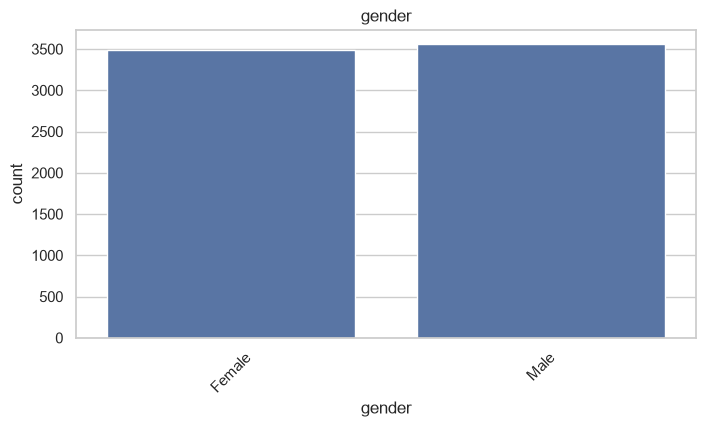

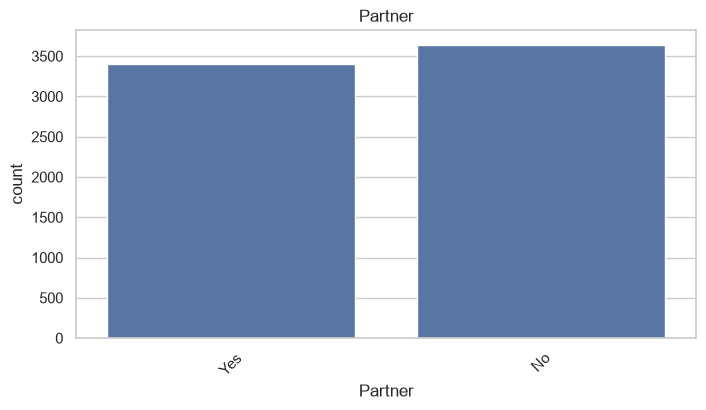

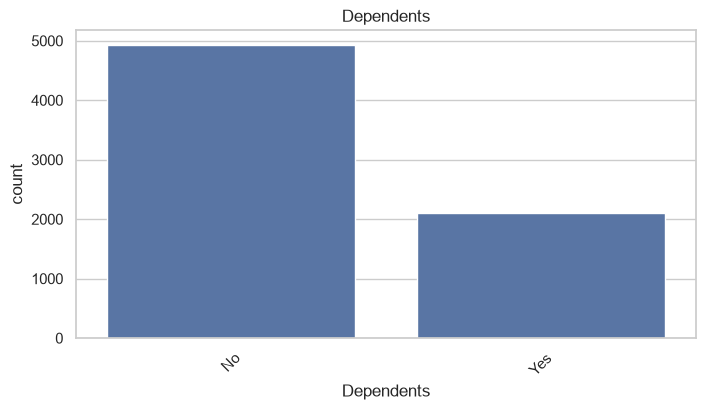

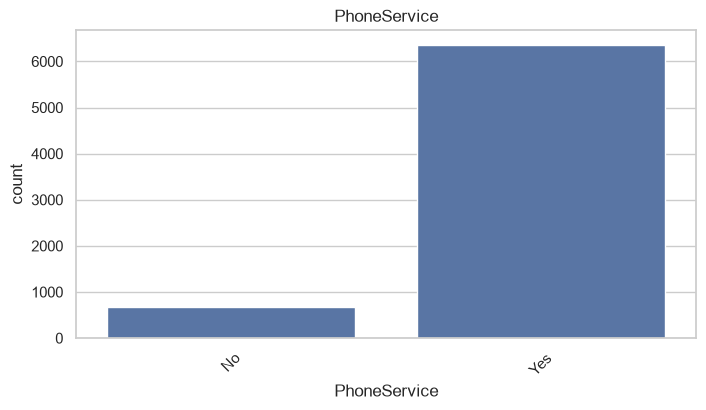

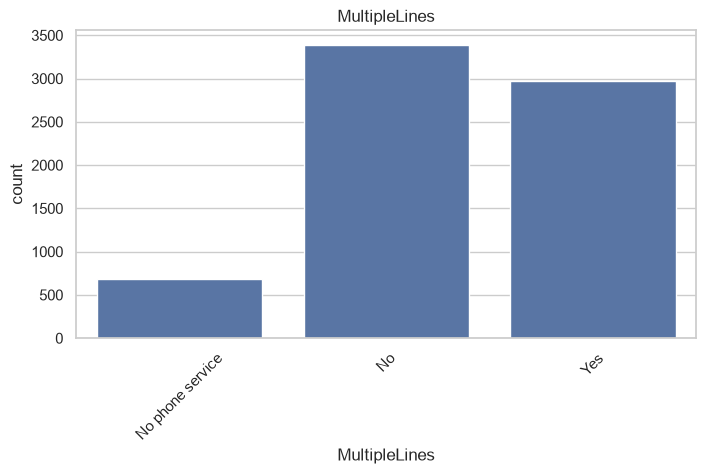

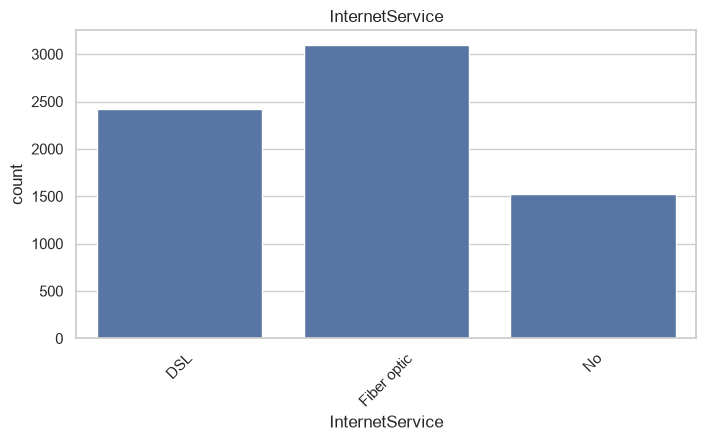

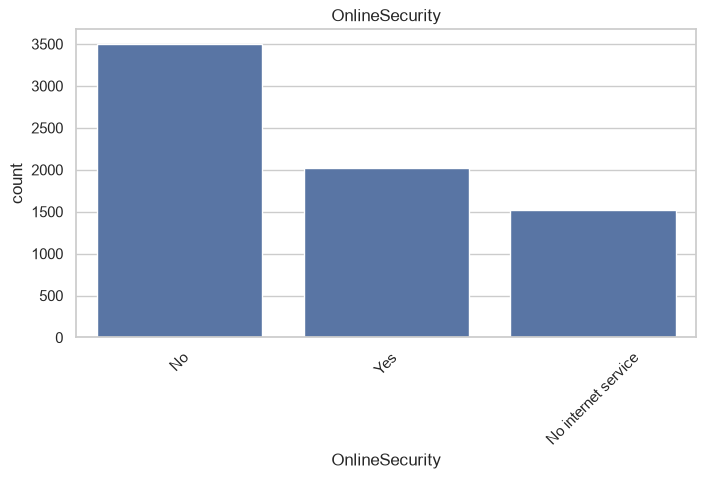

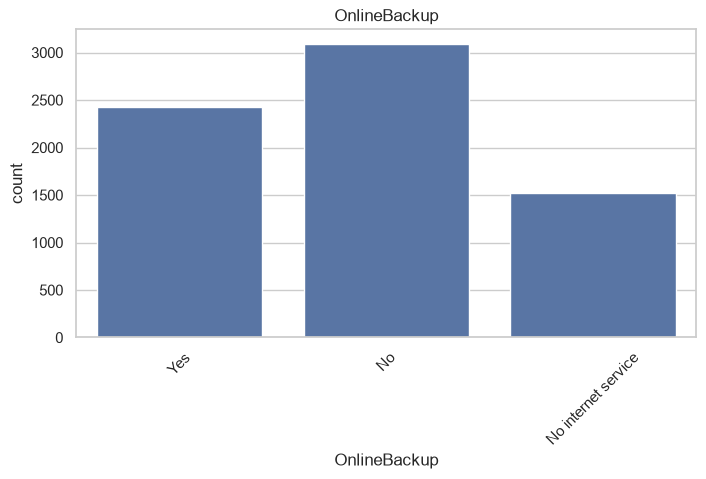

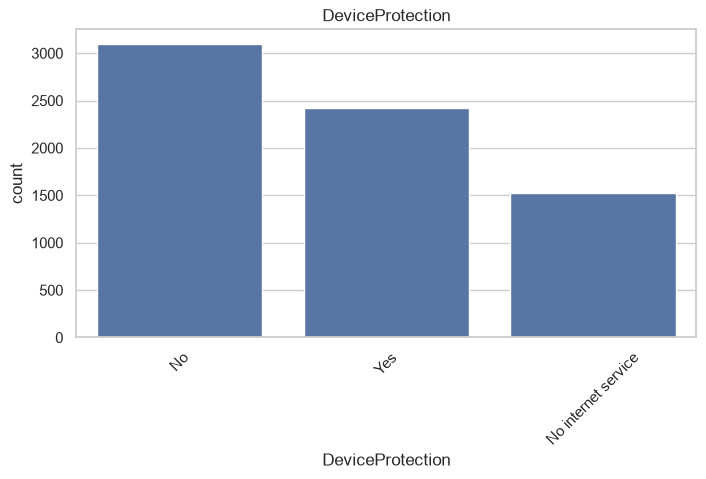

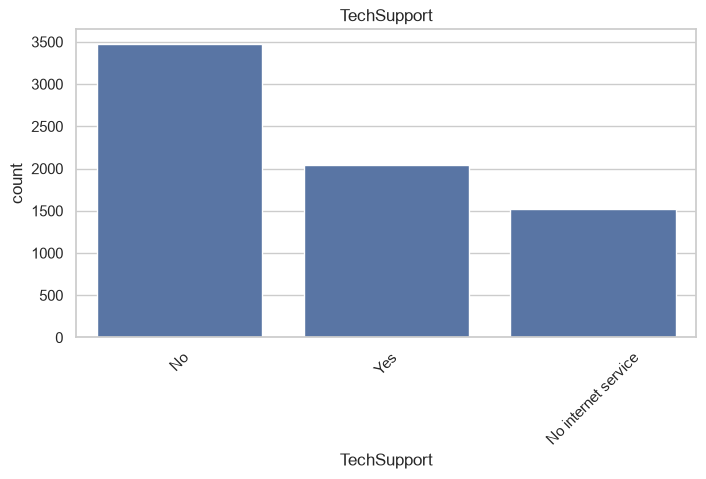

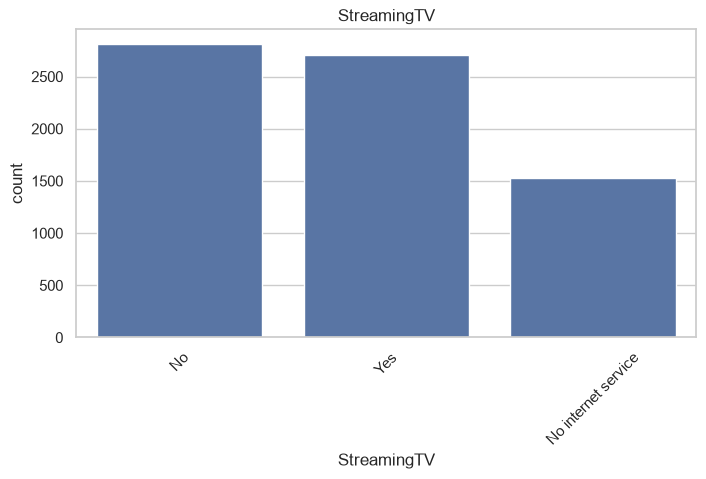

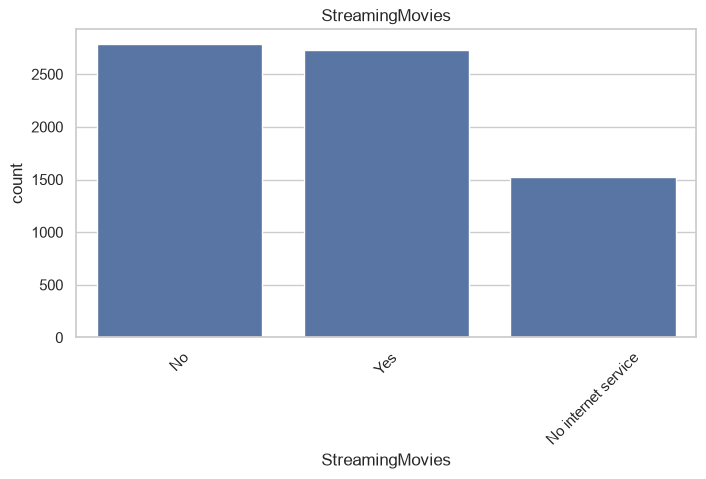

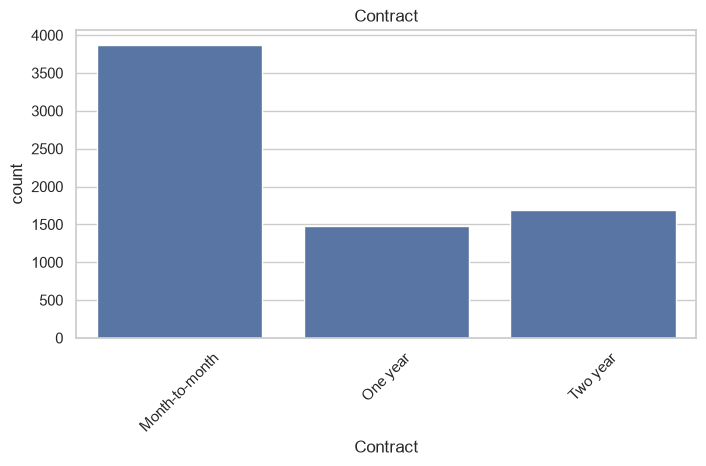

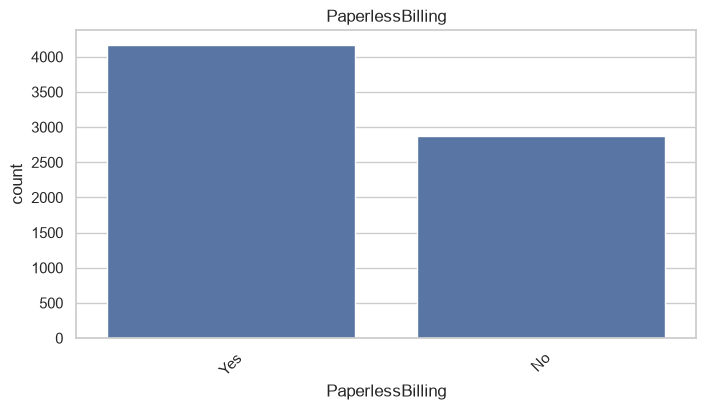

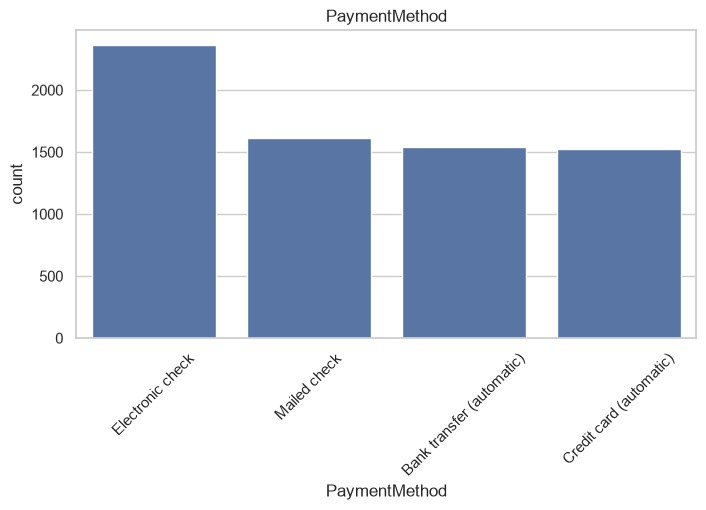

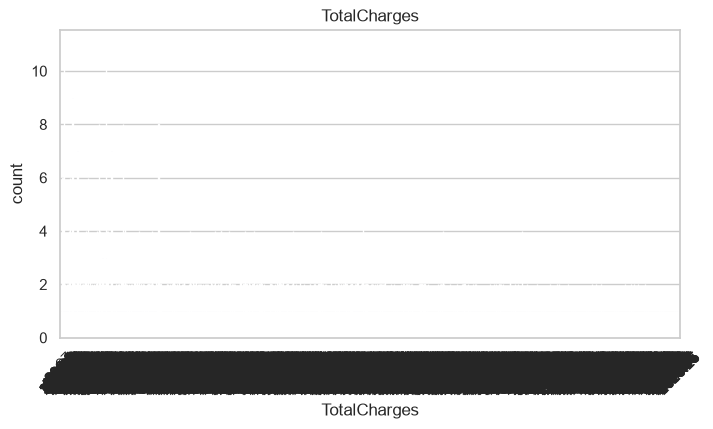

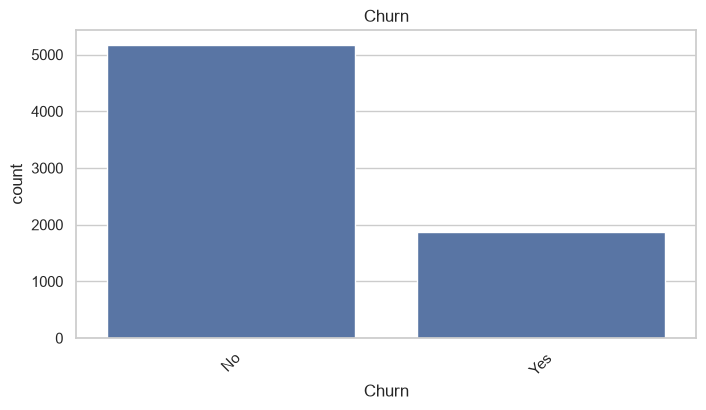

In [24]:
for col in categorical:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

Long-term contracts significantly improve customer retention.
Electronic check users may represent customers with less commitment or lower satisfaction.

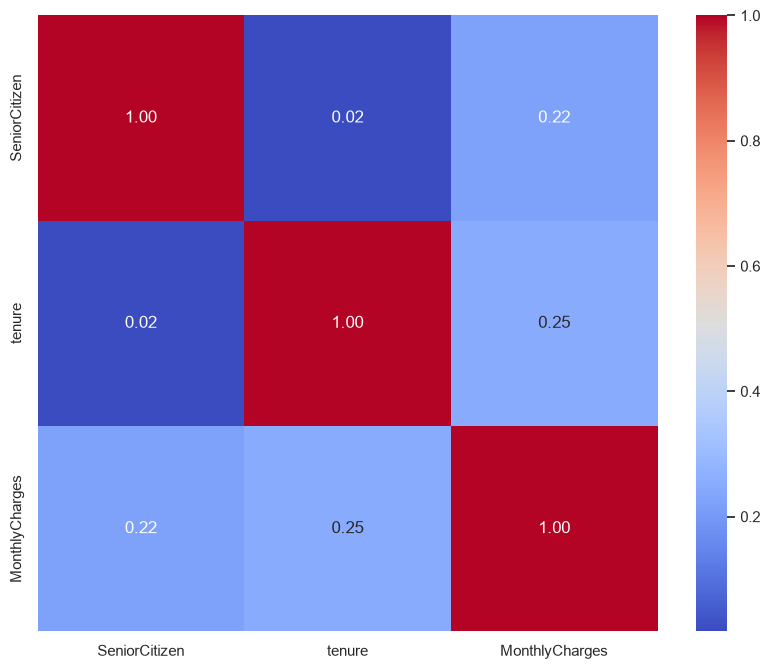

In [25]:
plt.figure(figsize=(10,8))

corr = df[numerical].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.show()

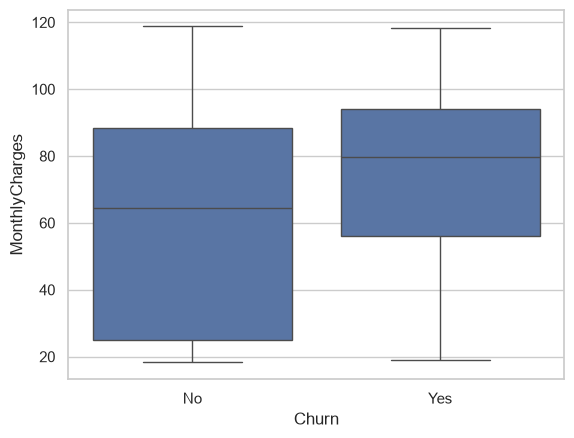

In [26]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.show()

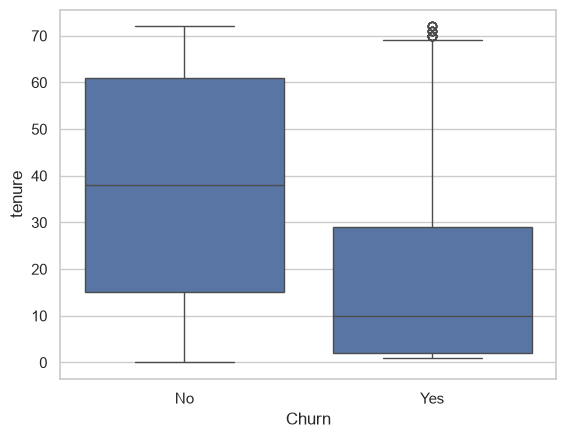

In [27]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.show()

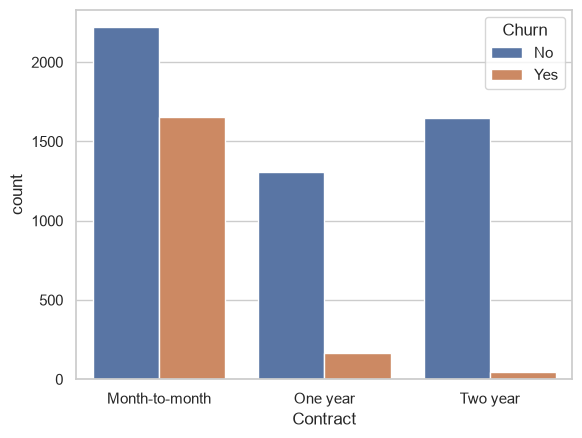

In [28]:
sns.countplot(data=df,
              x="Contract",
              hue="Churn")
plt.show()

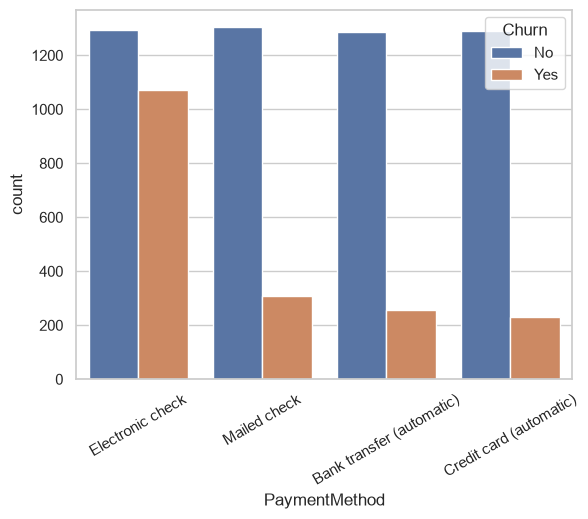

In [29]:
sns.countplot(data=df,
              x="PaymentMethod",
              hue="Churn")

plt.xticks(rotation=30)
plt.show()

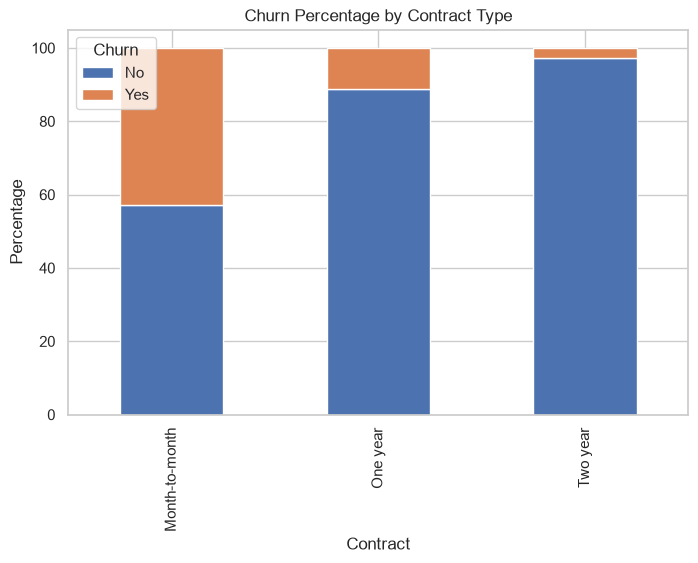

In [30]:
contract_churn = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
)

contract_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.ylabel("Percentage")
plt.title("Churn Percentage by Contract Type")
plt.show()

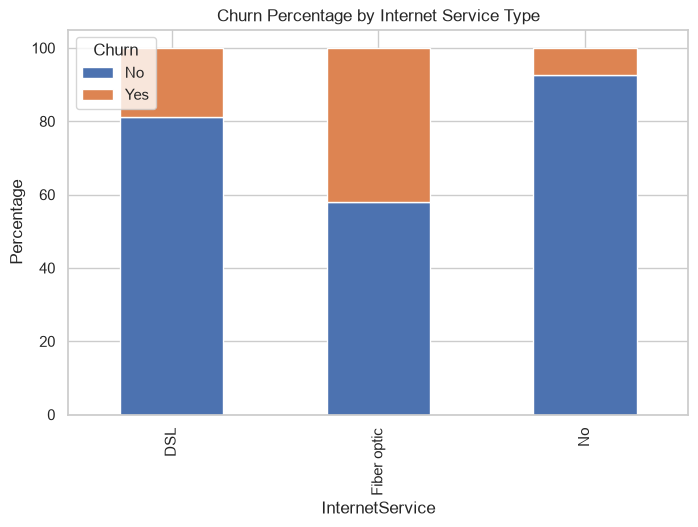

In [31]:
internet_service_churn = (
    pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
)

internet_service_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.ylabel("Percentage")
plt.title("Churn Percentage by Internet Service Type")
plt.show()

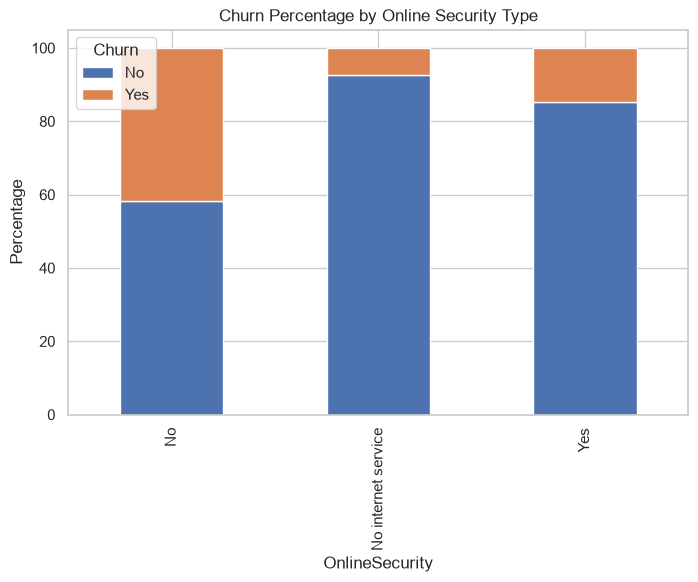

In [32]:
online_security_churn = (
    pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index") * 100
)

online_security_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.ylabel("Percentage")
plt.title("Churn Percentage by Online Security Type")
plt.show()

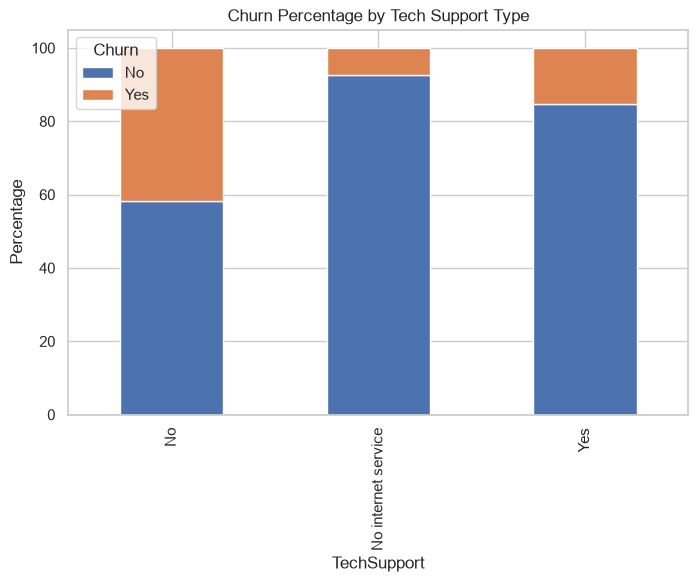

In [36]:
techn_support_churn = (
    pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100
)

techn_support_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.ylabel("Percentage")
plt.title("Churn Percentage by Tech Support Type")
plt.show()